In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import jax.numpy as jnp
import jax.random as jrand
import matplotlib.pyplot as plt
from gvabm.stat_utils import CityParams, EventOutcome, GeneralParams, logrange
from gvabm.city_data import subsampled_city_data, subsample_weights

has_event = np.array([len(d['events']) > 0 for d in subsampled_city_data])
param_mat = np.array([d['params'] for d in subsampled_city_data])
event_severity = np.array([d['events'][0][1] if len(d['events']) > 0 else 0 for d in subsampled_city_data])
population_density = param_mat[:, 1]
arm_density = param_mat[:, 3]
pop = param_mat[:, 0]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
alpha = 2.28
kmin = 5
#sample from power law distribution
samples = jrand.pareto

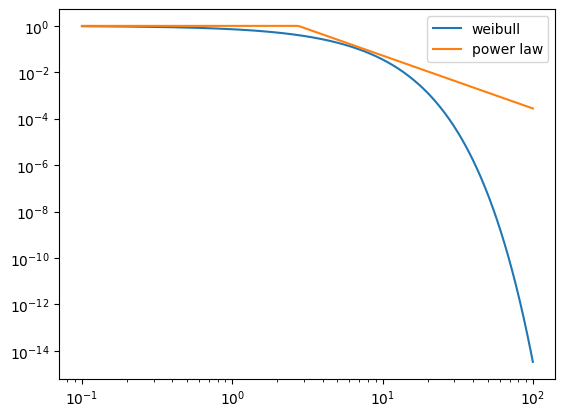

In [4]:
#Use scipy to plot a weibull distribution
from scipy.stats import weibull_min
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(0.1, 100, 1000)
# plt.plot(x, weibull_min.pdf(x, 0.5), label='weibull')
# plt.plot(x, weibull_min.pdf(x, 1.5), label='weibull')
plt.plot(x, weibull_min.pdf(x / 3, 1), label='weibull')
alpha, kmin = 2.28, 5
plt.plot(x, np.minimum(1, (alpha - 1) / kmin * (x / kmin) ** (-alpha)), label='power law')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()


In [6]:
from gvabm.abm_ll import eval_ds
from gvabm.param_distr import ParamDistr, param_config
param_distr = ParamDistr(param_config)
# x0 = np.array([-7.49712599, 38.49844685,  0.70090904, -1.13903331, -4.42167238])

#propensity, walk_radius, arm_bias, arm_weight, gather_risk_rate
x0 = np.array([-7.50, 25.1,  -0.6, -0.1, -4.42167238])
params = param_distr.transform_sample(x0)
general_params = GeneralParams(*np.array(params))
arm_bias_range = np.array([-0.85])#jnp.linspace(-8, -0.4, 2, endpoint=False)
arm_weight_range = jnp.linspace(-2.7, 0.5, 12)
print(general_params)

GeneralParams(propensity=np.float32(3.162278e-08), walk_radius=np.float32(25.1), arm_bias=np.float32(0.25118864), arm_weight=np.float32(0.7943283), atrisk_gathering_rate=np.float32(3.7872804e-05))


In [3]:
c_params = np.array([c['params'] for c in subsampled_city_data])
event_ex_params = c_params[has_event][0]
noevent_ex_params = c_params[~has_event][0]

In [4]:
from abm_event import conditional_sample, conditional_sample_nopoisson
from stat_utils import grenander_pdf
from abm_ll import eval_ds

In [10]:
x0 = np.array([-8.00, 25.1,  -0.6, -0.1, -4.42167238])
params = param_distr.transform_sample(x0)
general_params = GeneralParams(*np.array(params))

cond_ll_eval = []
rng_key = jrand.PRNGKey(26)
for i in range(10):
    rng_key, subkey = jrand.split(rng_key)
    ll_data = eval_ds(subsampled_city_data, general_params, 50, subkey, num_samples=int(2e4), sample_func=conditional_sample)
    # ll_eval = ll_data*subsample_weights[:, None]
    # ll_eval = ll_eval.sum(axis=0)[0]
    # print(i, ll_eval)
    cond_ll_eval.append(ll_data)

In [20]:
city_ll_eval = np.array(cond_ll_eval)[:, :, 0]
city_ll_var = np.var(city_ll_eval, axis=0)
city_ll_mean = np.mean(city_ll_eval, axis=0)

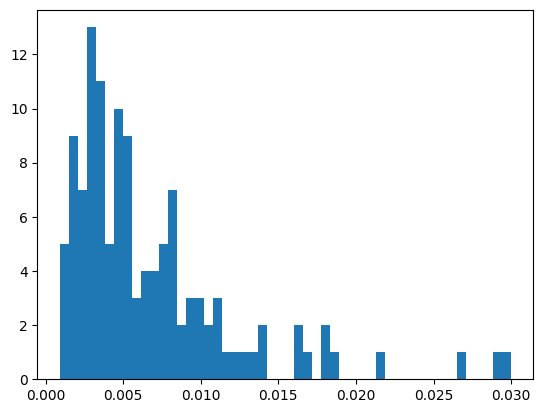

In [27]:
plt.hist(city_ll_var[has_event], bins=50)
plt.show()

In [130]:
eval_mat = np.zeros((len(arm_bias_range), len(arm_weight_range), len(subsampled_city_data), 3))
for i, arm_bias in enumerate(arm_bias_range):
    for j, arm_weight in enumerate(arm_weight_range):
        x_sample = x0.copy()
        x_sample[2] = arm_bias
        x_sample[3] = arm_weight
        params = param_distr.transform_sample(x_sample)
        general_params = GeneralParams(*np.array(params))
        print(general_params)
        city_eval = eval_ds(subsampled_city_data, general_params, 50, jrand.PRNGKey(0), num_samples=int(1e5))
        ll, pll, event_ll = city_eval[:, 0], city_eval[:, 1], city_eval[:, 2]
        eval_mat[i, j, :, 0] = ll
        eval_mat[i, j, :, 1] = pll
        eval_mat[i, j, :, 2] = event_ll

GeneralParams(propensity=np.float32(3.162278e-08), walk_radius=np.float32(25.1), arm_bias=np.float32(0.14125374), arm_weight=np.float32(0.001995262), atrisk_gathering_rate=np.float32(3.7872804e-05))
GeneralParams(propensity=np.float32(3.162278e-08), walk_radius=np.float32(25.1), arm_bias=np.float32(0.14125374), arm_weight=np.float32(0.0038986022), atrisk_gathering_rate=np.float32(3.7872804e-05))
GeneralParams(propensity=np.float32(3.162278e-08), walk_radius=np.float32(25.1), arm_bias=np.float32(0.14125374), arm_weight=np.float32(0.0038986022), atrisk_gathering_rate=np.float32(3.7872804e-05))
GeneralParams(propensity=np.float32(3.162278e-08), walk_radius=np.float32(25.1), arm_bias=np.float32(0.14125374), arm_weight=np.float32(0.007617599), atrisk_gathering_rate=np.float32(3.7872804e-05))
GeneralParams(propensity=np.float32(3.162278e-08), walk_radius=np.float32(25.1), arm_bias=np.float32(0.14125374), arm_weight=np.float32(0.007617599), atrisk_gathering_rate=np.float32(3.7872804e-05))
Gen

In [131]:
# result_dict = {}
result_dict[f"(bias: {', '.join([f'{b:.2f}' for b in arm_bias_range])}, weight: {', '.join([f'{b:.2f}' for b in arm_weight_range])}"] = eval_mat
np.savez_compressed("data/eval_grid.npz", **result_dict)

In [ ]:
#load saved result dict
# result_dict = np.load("data/eval_grid.npz", allow_pickle=True)

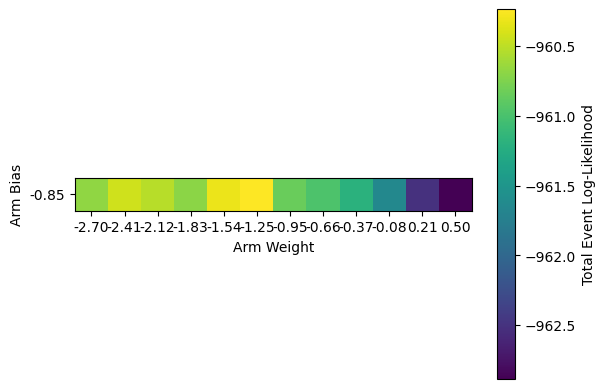

In [132]:
weighted_eval = eval_mat * subsample_weights.reshape((1, 1, -1, 1))
mat = weighted_eval[:, :, :, 0].sum(axis=-1)
mat[mat < mat.max() - 10] = mat.max() - 10
plt.imshow(mat, origin='lower')
plt.xticks(ticks=np.arange(len(arm_weight_range)), labels=[f"{w:.2f}" for w in arm_weight_range])
plt.yticks(ticks=np.arange(len(arm_bias_range)), labels=[f"{b:.2f}" for b in arm_bias_range])
plt.xlabel("Arm Weight")
plt.ylabel("Arm Bias")
plt.colorbar(label="Total Event Log-Likelihood")

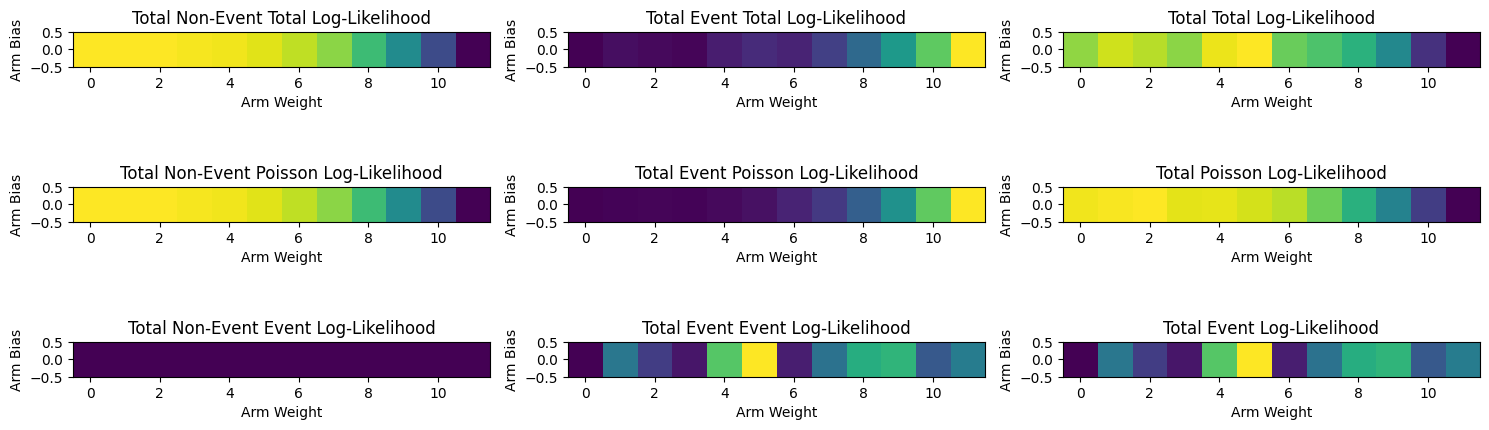

In [134]:
fig, ax = plt.subplots(3, 3, figsize=(15, 5))
ll_titles = ["Total Log-Likelihood", "Poisson Log-Likelihood", "Event Log-Likelihood"]
for i in range(3):
    ax[i, 0].imshow(weighted_eval[:, :, ~has_event, i].sum(axis=-1), origin='lower')
    # ax[i, 0].set_xticks(ticks=np.arange(len(arm_weight_range)), labels=[f"{w:.2f}" for w in arm_weight_range])
    # ax[i, 0].set_yticks(ticks=np.arange(len(arm_bias_range)), labels=[f"{b:.2f}" for b in arm_bias_range])
    ax[i, 0].set_xlabel("Arm Weight")
    ax[i, 0].set_ylabel("Arm Bias")
    ax[i, 0].set_title(f"Total Non-Event {ll_titles[i]}")
    ax[i, 1].imshow(weighted_eval[:, :, has_event, i].sum(axis=-1), origin='lower')
    # ax[i, 1].set_xticks(ticks=np.arange(len(arm_weight_range)), labels=[f"{w:.2f}" for w in arm_weight_range])
    # ax[i, 1].set_yticks(ticks=np.arange(len(arm_bias_range)), labels=[f"{b:.2f}" for b in arm_bias_range])
    ax[i, 1].set_xlabel("Arm Weight")
    ax[i, 1].set_ylabel("Arm Bias")
    ax[i, 1].set_title(f"Total Event {ll_titles[i]}")
    im = ax[i, 2].imshow(weighted_eval[:, :, :, i].sum(axis=-1), origin='lower')
    # ax[i, 2].set_xticks(ticks=np.arange(len(arm_weight_range)), labels=[f"{w:.2f}" for w in arm_weight_range])
    # ax[i, 2].set_yticks(ticks=np.arange(len(arm_bias_range)), labels=[f"{b:.2f}" for b in arm_bias_range])
    ax[i, 2].set_xlabel("Arm Weight")
    ax[i, 2].set_ylabel("Arm Bias")
    ax[i, 2].set_title(f"Total {ll_titles[i]}")
# fig.colorbar(im, ax=ax.ravel().tolist(), label="Total Log-Likelihood")
fig.tight_layout()

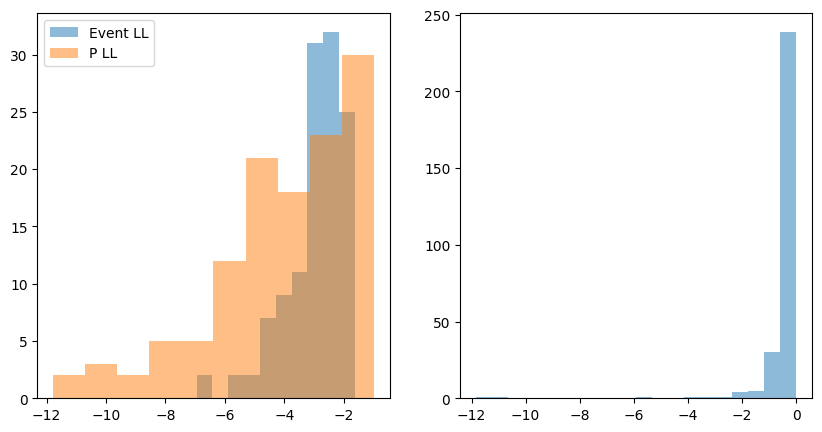

[-846.56610142 -487.61235035 -358.95375107]
[-114.74362394 -114.74362394    0.        ]


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].hist(event_ll[has_event], weights=subsample_weights[has_event], alpha=0.5, label='Event LL')
axs[0].hist(pll[has_event], weights=subsample_weights[has_event], alpha=0.5, label='P LL')
axs[0].legend()
axs[1].hist(pll[~has_event] * subsample_weights[~has_event], alpha=0.5, bins=20, label='P LL')
# axs[1].set_yscale('log')
plt.show()
print((city_eval[has_event]*subsample_weights[has_event].reshape(-1,1)).sum(axis=0))
print((city_eval[~has_event]*subsample_weights[~has_event].reshape(-1,1)).sum(axis=0))

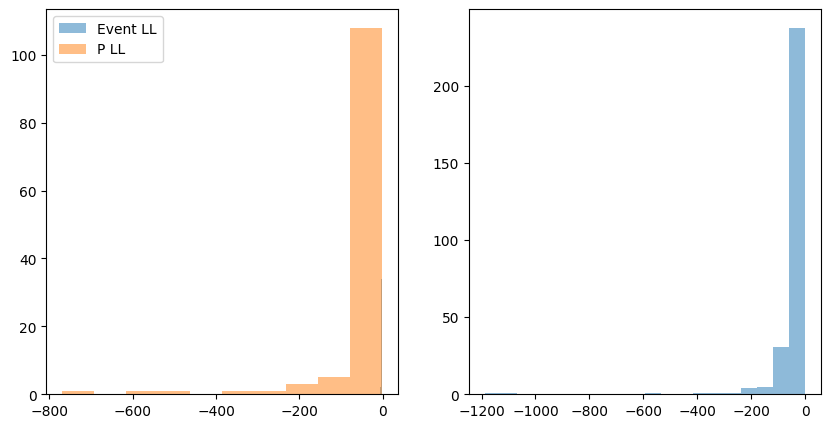

[-4900.20155429 -4541.23872029  -358.962834  ]
[-11472.5302037 -11472.5302037      0.       ]


In [67]:
x0 = np.array([-5.50, 25.1,  0.70, -1.12, -4.42167238])
params = param_distr.transform_sample(x0)
general_params = GeneralParams(*np.array(params))
city_eval = eval_ds(subsampled_city_data, general_params, 50, jrand.PRNGKey(0), num_samples=5000)
ll, pll, event_ll = city_eval[:, 0], city_eval[:, 1], city_eval[:, 2]
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].hist(event_ll[has_event], weights=subsample_weights[has_event], alpha=0.5, label='Event LL')
axs[0].hist(pll[has_event], weights=subsample_weights[has_event], alpha=0.5, label='P LL')
axs[0].legend()
axs[1].hist(pll[~has_event] * subsample_weights[~has_event], alpha=0.5, bins=20, label='P LL')
# axs[1].set_yscale('log')
plt.show()
print((city_eval[has_event]*subsample_weights[has_event].reshape(-1,1)).sum(axis=0))
print((city_eval[~has_event]*subsample_weights[~has_event].reshape(-1,1)).sum(axis=0))

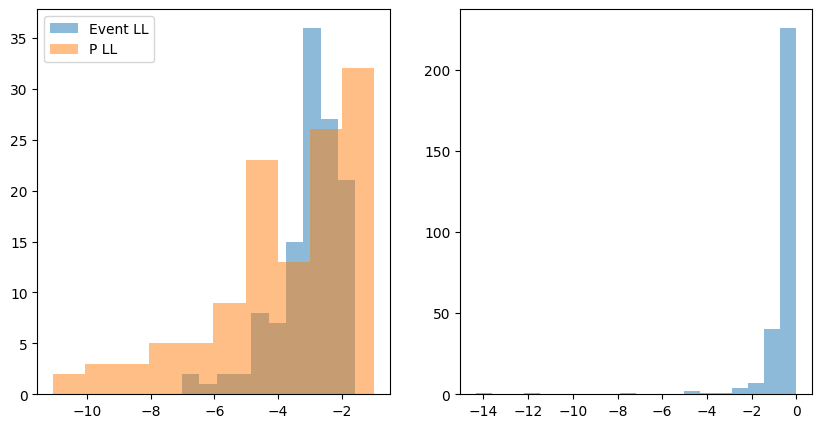

[-824.09369999 -457.38489459 -366.7088054 ]
[-149.83773743 -149.83773743    0.        ]


In [ ]:
x0 = np.array([-7.49712599, 38.49844685,  0.70090904, -1.13903331, -4.42167238])
params = param_distr.transform_sample(x0)
general_params = GeneralParams(*np.array(params))
city_eval = eval_ds(subsampled_city_data, general_params, 50, jrand.PRNGKey(0), num_samples=5000)
ll, pll, event_ll = city_eval[:, 0], city_eval[:, 1], city_eval[:, 2]
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].hist(event_ll[has_event], weights=subsample_weights[has_event], alpha=0.5, label='Event LL')
axs[0].hist(pll[has_event], weights=subsample_weights[has_event], alpha=0.5, label='P LL')
axs[0].legend()
axs[1].hist(pll[~has_event] * subsample_weights[~has_event], alpha=0.5, bins=20, label='P LL')
# axs[1].set_yscale('log')
plt.show()
print((city_eval[has_event]*subsample_weights[has_event].reshape(-1,1)).sum(axis=0))
print((city_eval[~has_event]*subsample_weights[~has_event].reshape(-1,1)).sum(axis=0))

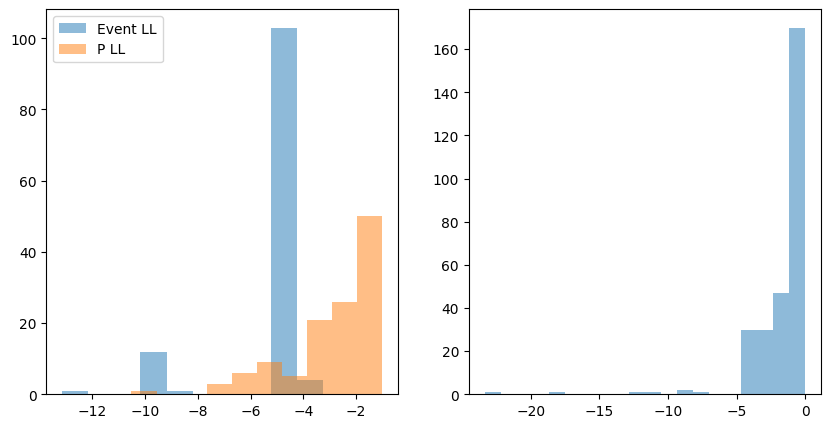

[-1000.52823366  -339.3370765   -661.19115716]
[-442.75599749 -442.75599749    0.        ]


In [ ]:
x0 = np.array([-7.49712599, 38.49844685,  0.70090904, -1.13903331, -2.42167238])
params = param_distr.transform_sample(x0)
general_params = GeneralParams(*np.array(params))
city_eval = eval_ds(subsampled_city_data, general_params, 50, jrand.PRNGKey(0), num_samples=5000)
ll, pll, event_ll = city_eval[:, 0], city_eval[:, 1], city_eval[:, 2]
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].hist(event_ll[has_event], weights=subsample_weights[has_event], alpha=0.5, label='Event LL')
axs[0].hist(pll[has_event], weights=subsample_weights[has_event], alpha=0.5, label='P LL')
axs[0].legend()
axs[1].hist(pll[~has_event] * subsample_weights[~has_event], alpha=0.5, bins=20, label='P LL')
# axs[1].set_yscale('log')
plt.show()
print((city_eval[has_event]*subsample_weights[has_event].reshape(-1,1)).sum(axis=0))
print((city_eval[~has_event]*subsample_weights[~has_event].reshape(-1,1)).sum(axis=0))

In [ ]:
ll, pll, event_ll = city_eval[:, 0], city_eval[:, 1], city_eval[:, 2]
#plot histograms of ll, pll, event_ll using subsample_weights as weights and separating by has_event on six subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
axs[0].hist(ll[has_event], bins=30, weights=subsample_weights[has_event], alpha=0.5, label='Event')
axs[0].hist(ll[~has_event], bins=30, weights=subsample_weights[~has_event], alpha=0.5, label='No Event')
axs[0].set_title('Log-Likelihood')
axs[0].legend()
axs[1].hist(pll[has_event], bins=30, weights=subsample_weights[has_event], alpha=0.5, label='Event')
axs[1].hist(pll[~has_event], bins=30, weights=subsample_weights[~has_event], alpha=0.5, label='No Event')
axs[1].set_title('Penalized Log-Likelihood')
axs[1].legend()
axs[2].hist(event_ll[has_event], bins=30, weights=subsample_weights[has_event], alpha=0.5, label='Event')
axs[2].hist(event_ll[~has_event], bins=30, weights=subsample_weights[~has_event], alpha=0.5, label='No Event')
axs[2].set_title('Event Log-Likelihood')
axs[2].legend()
plt.show()

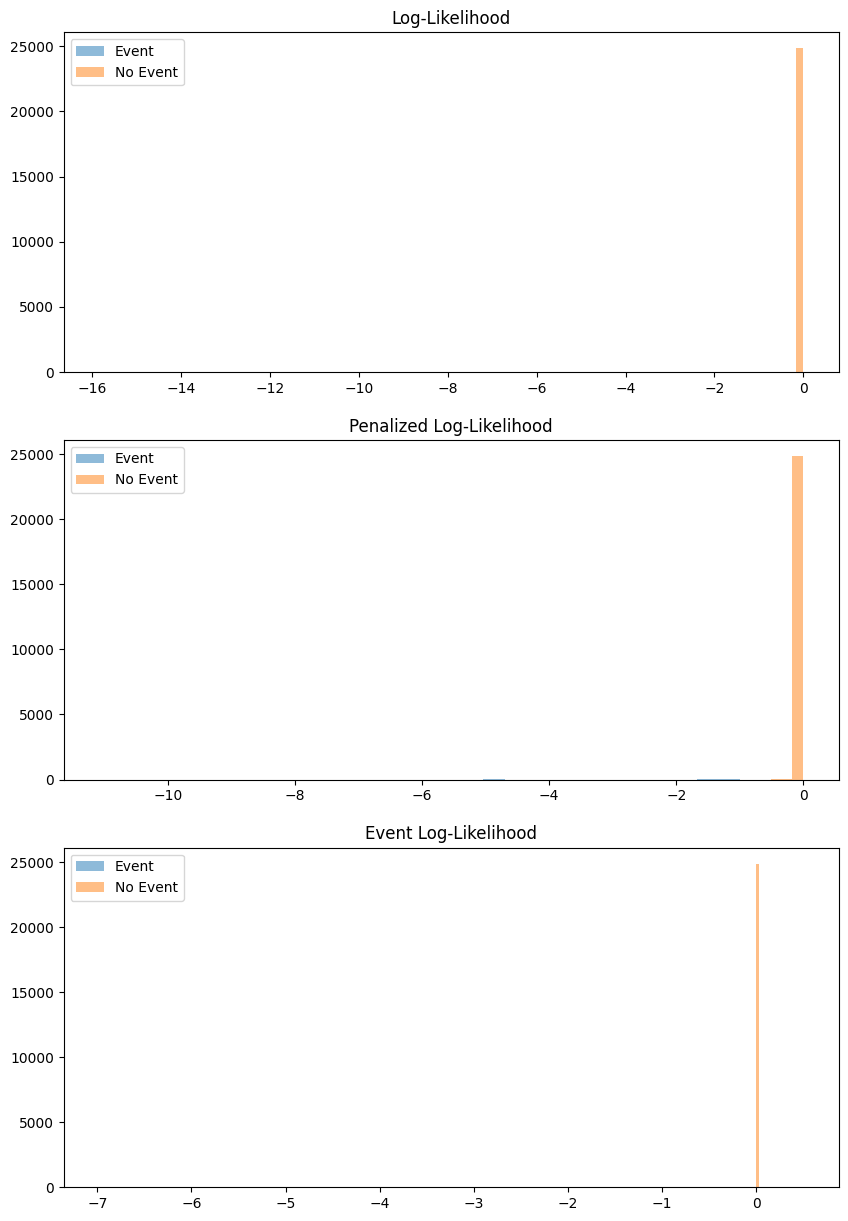

In [13]:
ll, pll, event_ll = city_eval[:, 0], city_eval[:, 1], city_eval[:, 2]
#plot histograms of ll, pll, event_ll using subsample_weights as weights and separating by has_event on six subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
axs[0].hist(ll[has_event], bins=30, weights=subsample_weights[has_event], alpha=0.5, label='Event')
axs[0].hist(ll[~has_event], bins=30, weights=subsample_weights[~has_event], alpha=0.5, label='No Event')
axs[0].set_title('Log-Likelihood')
axs[0].legend()
axs[1].hist(pll[has_event], bins=30, weights=subsample_weights[has_event], alpha=0.5, label='Event')
axs[1].hist(pll[~has_event], bins=30, weights=subsample_weights[~has_event], alpha=0.5, label='No Event')
axs[1].set_title('Penalized Log-Likelihood')
axs[1].legend()
axs[2].hist(event_ll[has_event], bins=30, weights=subsample_weights[has_event], alpha=0.5, label='Event')
axs[2].hist(event_ll[~has_event], bins=30, weights=subsample_weights[~has_event], alpha=0.5, label='No Event')
axs[2].set_title('Event Log-Likelihood')
axs[2].legend()
plt.show()

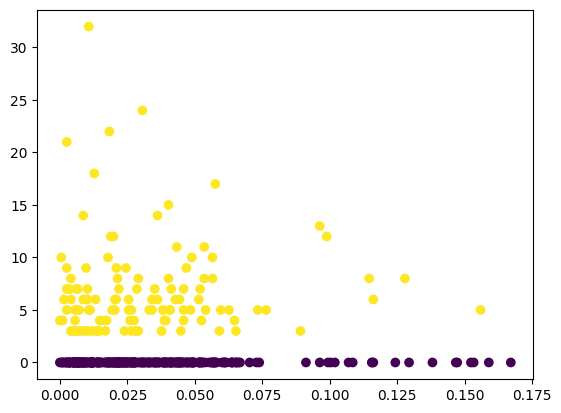

In [5]:
plt.scatter(arm_density, event_severity, c=has_event)
plt.show()

In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jrand

def sample_event(walk_radius, population_density, arm_density, atrisk_gathering_rate, rng_key):
    rng_key, subkey = jrand.split(rng_key)
    population_grid = jnp.full((30, 30), population_density)

    access_count = jrand.poisson(subkey, lam=arm_density * population_grid.size)

    flat_pop_grid = population_grid.flatten()
    probabilities = flat_pop_grid / jnp.sum(flat_pop_grid)
    
    rng_key, subkey = jrand.split(rng_key)

    max_access = 250
    access_points = jrand.choice(subkey, population_grid.size, (max_access,), p=probabilities)
    point_mask = jnp.arange(max_access) < access_count
    access_grid = jnp.zeros_like(population_grid)
    access_grid = access_grid.at[jnp.unravel_index(access_points, population_grid.shape)].set(point_mask)
    
    rng_key, subkey = jrand.split(rng_key)
    random_walk = jrand.randint(subkey, (100, 2), -1, 2)
    random_walk = jnp.cumsum(random_walk, axis=0) % population_grid.shape[0]
    walk_mask = jnp.arange(100) < walk_radius
    
    weapon_access = jnp.any(access_grid[random_walk[:, 0], random_walk[:, 1]]*walk_mask)

    walk_grid = jnp.zeros_like(population_grid)
    walk_grid = walk_grid.at[random_walk[:, 0], random_walk[:, 1]].set(walk_mask)
    # atrisk_gathering_rate = 1e-6
    population_encounters = jnp.sum(walk_grid * population_grid)
    rng_key, subkey = jrand.split(rng_key)

    max_location = 50
    location_count = jrand.poisson(subkey, lam=population_encounters * atrisk_gathering_rate)
    location_mask = jnp.arange(max_location) < location_count
    rng_key, subkey = jrand.split(rng_key)
    loc_gathering_size = jrand.weibull_min(subkey, 10, 0.4, (max_location,))
    gathering_size = jnp.max(loc_gathering_size*location_mask, initial=0)
    rng_key, subkey = jrand.split(rng_key)
    
    event_magnitude = ((access_count > 0) & weapon_access & (location_count > 0)) * jrand.uniform(subkey, (), minval=0, maxval=gathering_size)
    
    # Return event magnitude along with metadata
    return event_magnitude, access_count, location_count

batch_sample = jax.jit(jax.vmap(sample_event, 0), device=jax.devices()[0])
from stat_utils import CityParams, GeneralParams
def conditional_sample(city_params: CityParams, general_params: GeneralParams, rng_key, num_samples=10000):
    population, population_density, arm_count, arm_density = city_params
    propensity, walk_radius, arm_bias, arm_weight, atrisk_gathering_rate = general_params
    rng_batch = jrand.split(rng_key, num_samples)
    event_results = batch_sample(jnp.full(num_samples, walk_radius), jnp.full(num_samples, population_density), 
                                 jnp.full(num_samples, arm_density*arm_weight+arm_bias), 
                                 jnp.full(num_samples, atrisk_gathering_rate), rng_batch)
    
    event_samples, access_counts, gathering_counts = event_results
    pseudocount_samples = jnp.concatenate([event_samples, jnp.array([10, 100, 1000])])
    metadata = {
        'access_counts': access_counts,
        'gathering_counts': gathering_counts,
        'mean_access_count': jnp.mean(access_counts),
        'mean_gathering_count': jnp.mean(gathering_counts)
    }
    return pseudocount_samples, metadata

In [14]:
from city_data import city_data_l
city_params = city_data_l[0][1]['params']
city_params_we = next(iter(city_data_l[i][1]['params'] for i in range(len(city_data_l)) if city_data_l[i][1]['events']))

In [17]:
samples, metadata = conditional_sample(city_params_we, GeneralParams(1e-6, 10, 0.1, 1, 1e-4), jrand.PRNGKey(0), num_samples=100000)

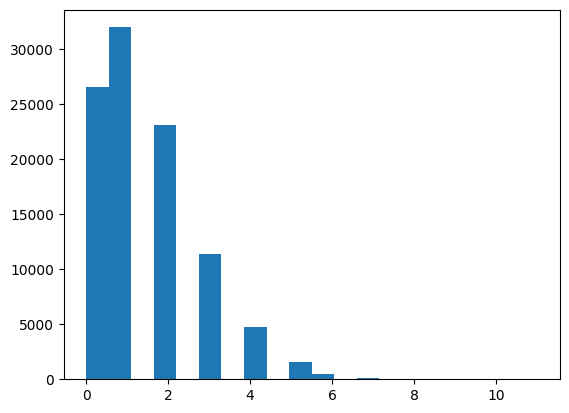

In [22]:
metadata
plt.hist(metadata['gathering_counts'], bins=20)
plt.show()

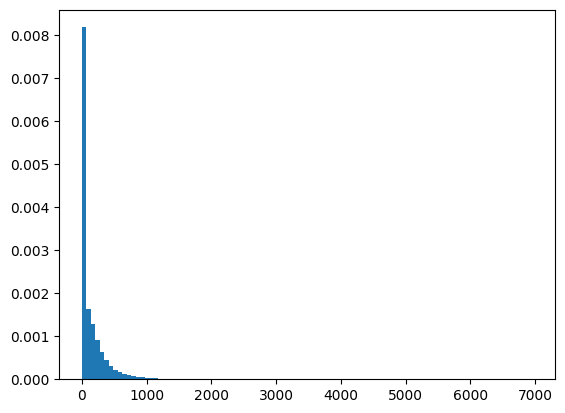

In [12]:
import matplotlib.pyplot as plt
plt.hist(samples, bins=100, density=True)
# plt.yscale('log')
plt.show()

In [53]:
has_event = np.array([len(d[1]['events']) > 0 for d in city_data_l])
event_severity = np.array([d[1]['events'][0][1] if len(d[1]['events']) > 0 else 0 for d in city_data_l])
param_mat = np.array([d[1]['params'] for d in city_data_l])
population_density = param_mat[:, 1]
arm_density = param_mat[:, 3]

In [54]:
# arm_density[has_event].mean(), arm_density[~has_event].mean() # 0.031, 0.015
import statsmodels.api as sm
X = sm.add_constant(arm_density)
model = sm.OLS(event_severity, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     67.17
Date:                Mon, 15 Sep 2025   Prob (F-statistic):           2.60e-16
Time:                        12:31:54   Log-Likelihood:                -22101.
No. Observations:               27696   AIC:                         4.421e+04
Df Residuals:                   27694   BIC:                         4.422e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0078      0.004      1.881      0.0

In [58]:
model = sm.Logit(has_event, X)
results = model.fit()
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.608802
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  405
Model:                          Logit   Df Residuals:                      403
Method:                           MLE   Df Model:                            1
Date:                Mon, 15 Sep 2025   Pseudo R-squ.:                0.001660
Time:                        12:32:23   Log-Likelihood:                -246.56
converged:                       True   LL-Null:                       -246.97
Covariance Type:            nonrobust   LLR p-value:                    0.3651
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7420      0.164     -4.534      0.000      -1.063      -0.421
x1            -3.3878      3.

In [96]:
has_event = np.array([len(d['events']) > 0 for d in subsampled_city_data])
param_mat = np.array([d['params'] for d in subsampled_city_data])
event_severity = np.array([d['events'][0][1] if len(d['events']) > 0 else 0 for d in subsampled_city_data])
population_density = param_mat[:, 1]
arm_density = param_mat[:, 3]

In [106]:
#Use sklearn to normalize population_density and arm_density to [0, 1]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
population_density = scaler.fit_transform(population_density.reshape(-1, 1)).flatten()
arm_density = scaler.fit_transform(arm_density.reshape(-1, 1)).flatten()

In [107]:
X = sm.add_constant(np.column_stack((arm_density, population_density)))

weighted_model = sm.GLM(has_event, X, family=sm.families.Binomial(), var_weights=subsample_weights)
weighted_results = weighted_model.fit()
print(weighted_results.summary(xname=['Intercept', 'Arm Density', 'Population Density']))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  405
Model:                            GLM   Df Residuals:                      402
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -718.35
Date:                Mon, 15 Sep 2025   Deviance:                       1436.7
Time:                        13:05:24   Pearson chi2:                 2.07e+04
No. Iterations:                     9   Pseudo R-squ. (CS):             0.2090
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -6.0386      0

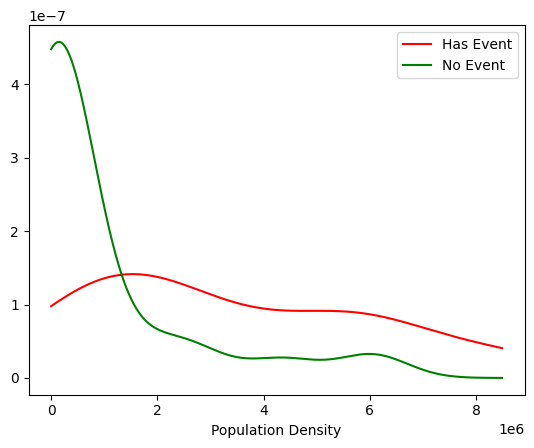

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import statsmodels.api as sm

# plt.scatter(population_density, has_event, color='blue', alpha=0.5, s=3)
k1 = gaussian_kde(pop[has_event], weights=subsample_weights[has_event] * pop[has_event])
k2 = gaussian_kde(pop[~has_event], weights=subsample_weights[~has_event] * pop[~has_event])
x = np.linspace(pop.min(), pop.max(), 1000)
plt.plot(x, k1(x), color='red', label='Has Event', zorder=1)
plt.plot(x, k2(x), color='green', label='No Event', zorder=1)
plt.xlabel('Population Density')
plt.legend()

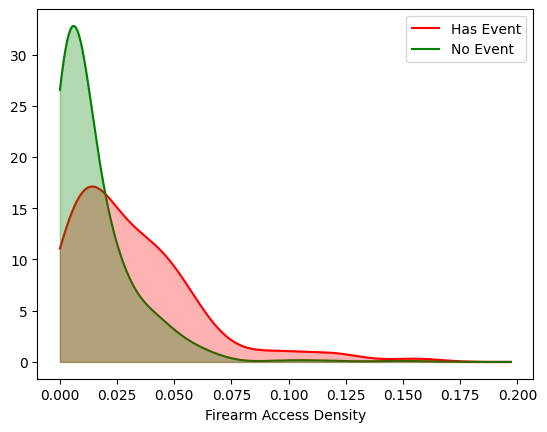

In [9]:
# plt.scatter(population_density, has_event, color='blue', alpha=0.5, s=3)
k1 = gaussian_kde(arm_density[has_event], weights=subsample_weights[has_event])
k2 = gaussian_kde(arm_density[~has_event], weights=subsample_weights[~has_event])
x = np.linspace(arm_density.min(), arm_density.max()+0.03, 1000)
plt.plot(x, k1(x), color='red', label='Has Event', zorder=1)
plt.plot(x, k2(x), color='green', label='No Event', zorder=1)
plt.fill_between(x, 0, k1(x), color='red', alpha=0.3)
plt.fill_between(x, 0, k2(x), color='green', alpha=0.3)
plt.xlabel('Firearm Access Density')
plt.legend()


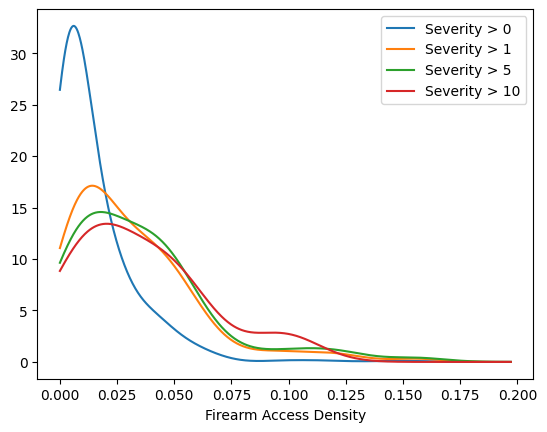

In [11]:
for threshold in [0, 1, 5, 10]:
    # plt.scatter(population_density, has_event, color='blue', alpha=0.5, s=3)
    k = gaussian_kde(arm_density[event_severity >= threshold], weights=subsample_weights[event_severity >= threshold])
    x = np.linspace(arm_density.min(), arm_density.max()+0.03, 1000)
    plt.plot(x, k(x), label=f'Severity > {threshold}', zorder=1)
plt.xlabel('Firearm Access Density')
plt.legend()

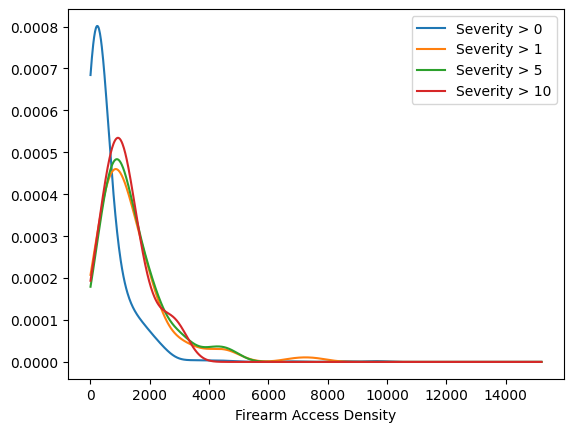

In [12]:
for threshold in [0, 1, 5, 10]:
    # plt.scatter(population_density, has_event, color='blue', alpha=0.5, s=3)
    k = gaussian_kde(population_density[event_severity >= threshold], weights=subsample_weights[event_severity >= threshold])
    x = np.linspace(population_density.min(), population_density.max()+0.03, 1000)
    plt.plot(x, k(x), label=f'Severity > {threshold}', zorder=1)
plt.xlabel('Firearm Access Density')
plt.legend()

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  405
Model:                            GLM   Df Residuals:                      403
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -735.96
Date:                Mon, 15 Sep 2025   Deviance:                       1471.9
Time:                        12:57:05   Pearson chi2:                 2.28e+04
No. Iterations:                     8   Pseudo R-squ. (CS):             0.1372
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.8073      0.117    -49.595      0.0

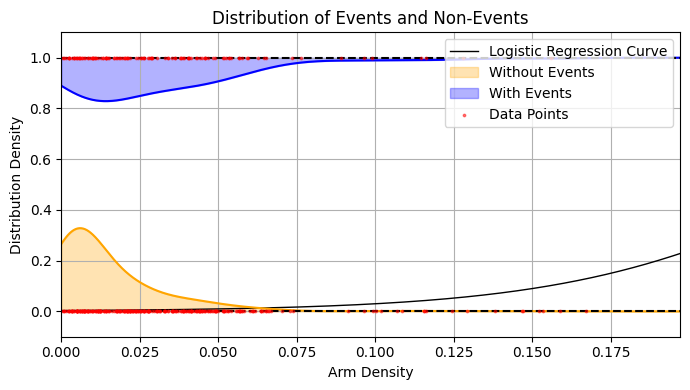

In [97]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import statsmodels.api as sm


X = sm.add_constant(arm_density)

weighted_model = sm.GLM(has_event, X, family=sm.families.Binomial(), var_weights=subsample_weights)
weighted_results = weighted_model.fit()
print(weighted_results.summary())

x = np.linspace(arm_density.min(), arm_density.max()+0.03, 1000)
y_pred = weighted_results.predict(sm.add_constant(x))

plt.figure(figsize=(7, 4))

# a. Plot the original data points
# Use a 'jitter' on the y-axis to better visualize overlapping points
# sns.stripplot(x=arm_density, y=has_event, jitter=0.1, alpha=0.6, size=5, palette='viridis', zorder=1)

# b. Plot the logistic regression curve
plt.plot(x, y_pred, color='black', linewidth=1, label='Logistic Regression Curve')
k1 = gaussian_kde(arm_density[has_event], weights=subsample_weights[has_event])
k2 = gaussian_kde(arm_density[~has_event], weights=subsample_weights[~has_event])


d2 = 0.01*k2(x)
plt.fill_between(x, 0, d2, color='orange', alpha=0.3, label='Without Events')
plt.plot(x, d2, color='orange') # Add the line for clarity

# b. Plot k1 (with events) upside down, with its base on y=1
# We invert the values and shift them up so the base is at y=1
d1 = 0.01*k1(x)
inverted_k1 = 1 - d1
plt.fill_between(x, inverted_k1, 1, color='blue', alpha=0.3, label='With Events')
plt.plot(x, inverted_k1, color='blue') # Add the line for clarity

# Add horizontal lines to mark the bases
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=1, color='black', linestyle='--')

# Set labels and title
plt.title('Distribution of Events and Non-Events')
plt.xlabel('Arm Density')

plt.scatter(arm_density, has_event, color='red', alpha=0.5, s=3, label='Data Points', zorder=2)

# Add a legend
plt.legend(loc='upper right')

# Set y-axis limits to clearly separate the plots
plt.ylim(-0.1, 1.1)
plt.xlim(arm_density.min(), arm_density.max()+0.03)

plt.grid(axis='x')
plt.grid(axis='y')
plt.ylabel('Distribution Density')

plt.tight_layout()
plt.show()

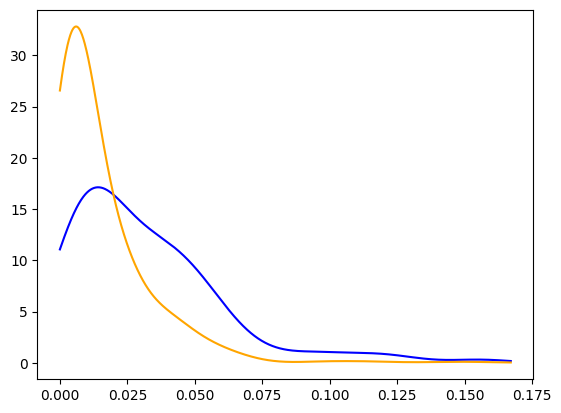

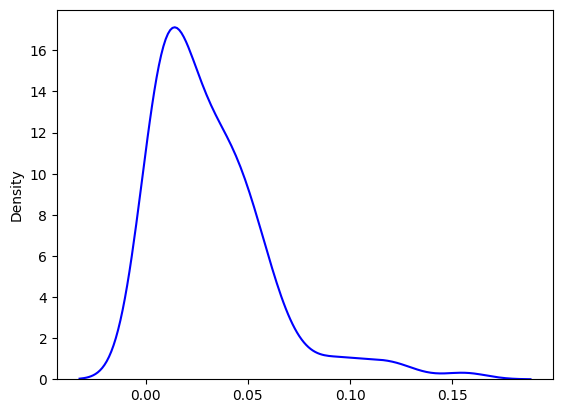

In [48]:
arm_density_pdf = sns.kdeplot(arm_density[has_event], label='With Events', color='blue')

In [43]:
subsample_weights[has_event].shape

(121,)

/tmp/ipykernel_3067260/2113057972.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=X, y=y, jitter=0.1, alpha=0.6, size=5, palette='viridis', zorder=1)


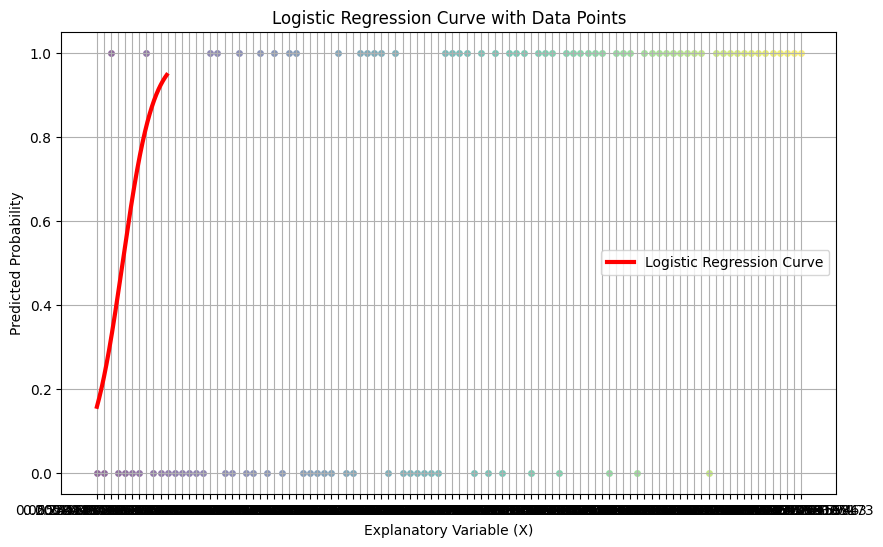

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# 1. Generate some sample data
np.random.seed(42)
n_samples = 100
X = np.random.uniform(0, 10, size=n_samples)
true_probabilities = 1 / (1 + np.exp(-(0.5 * X - 2)))
y = np.random.binomial(1, true_probabilities)

# 2. Fit the logistic regression model
X_with_constant = sm.add_constant(X)
model = sm.Logit(y, X_with_constant)
results = model.fit(disp=0) # disp=0 suppresses convergence output

# 3. Create a range of x values to plot the curve
x_range = np.linspace(X.min(), X.max(), 500)
x_range_with_constant = sm.add_constant(x_range)

# 4. Predict probabilities for the x range
y_predicted = results.predict(x_range_with_constant)

# 5. Create the plot
plt.figure(figsize=(10, 6))

# a. Plot the original data points
# Use a 'jitter' on the y-axis to better visualize overlapping points
sns.stripplot(x=X, y=y, jitter=0.1, alpha=0.6, size=5, palette='viridis', zorder=1)

# b. Plot the logistic regression curve
plt.plot(x_range, y_predicted, color='red', linewidth=3, label='Logistic Regression Curve')

# c. Add labels and a title
plt.title('Logistic Regression Curve with Data Points')
plt.xlabel('Explanatory Variable (X)')
plt.ylabel('Predicted Probability')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
subsampled_city_data


In [ ]:
#run linear regression of event_severity on arm_density, weighted by subsample_weights, get confidence intervals. 


                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.003
Model:                            WLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.282
Date:                Mon, 15 Sep 2025   Prob (F-statistic):              0.258
Time:                        11:45:23   Log-Likelihood:                -646.70
No. Observations:                 405   AIC:                             1297.
Df Residuals:                     403   BIC:                             1305.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0067      0.036      0.184      0.8

In [14]:
weighted_model = sm.Logit(has_event, X)
weighted_results = weighted_model.fit()
# print(weighted_results.summary())

Optimization terminated successfully.
         Current function value: 0.608802
         Iterations 5


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  405
Model:                            GLM   Df Residuals:                      403
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -735.96
Date:                Mon, 15 Sep 2025   Deviance:                       1471.9
Time:                        12:10:18   Pearson chi2:                 2.28e+04
No. Iterations:                     8   Pseudo R-squ. (CS):             0.1372
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.8073      0.117    -49.595      0.0

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [ ]:
glm = smf.glm(
    "affairs ~ rate_marriage + age + yrs_married",
    data=data,
    family=sm.families.Poisson(),
)
res_o = glm.fit()
print(res_o.summary())

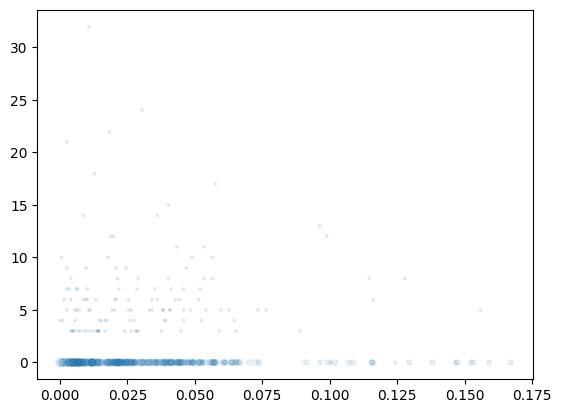

In [60]:
plt.scatter(arm_density, event_severity, alpha=0.1, s=5*np.log(subsample_weights+1))

In [53]:
print((arm_density[has_event]*subsample_weights[has_event]).sum() / subsample_weights[has_event].sum())
print((arm_density[~has_event]*subsample_weights[~has_event]).sum() / subsample_weights[~has_event].sum())

0.03142390903826921
0.014398323506274319
